## EXAMEN DATA SCIENCE 2
naam:   \
klas:    \
\
Voor je de file oplaadt, zorg ervoor dat alle cellen uitgevoerd zijn, zodat jouw resultaat ook weergegeven wordt!

### 0. Zet hier je imports

In [1]:
# imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from simanneal import Annealer
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

2025-06-16 16:27:14.574009: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### 1. Indexing

In [2]:
# a) De output is: 2

In [3]:
# b)
#df.loc[3:4,"C"]

### 2. Laad de 'Cars.csv' file

In [4]:
df = pd.read_csv('./Cars.csv', sep=';')

df.head(5)

,Manufacturer,Type,Min.Price,Price,Max.Price,MPG.city,MPG.highway,AirBags,DriveTrain,Cylinders,...,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Weight,Origin,Model
0,Acura,Small,12.9,15.9,18.8,25,31,No airbag,Front,4,...,5,177,102,68,37,26.5,11.0,2705,non-USA,Acura Integra
1,Acura,Midsize,29.2,33.9,38.7,18,25,Driver & Passenger,Front,6,...,5,195,115,71,38,30.0,15.0,3560,non-USA,Acura Legend
2,Audi,Compact,25.9,29.1,32.3,20,26,Driver only,Front,6,...,5,180,102,67,37,28.0,14.0,3375,non-USA,Audi 90
3,Audi,Midsize,30.8,37.7,44.6,19,26,Driver & Passenger,Front,6,...,6,193,106,70,37,31.0,17.0,3405,non-USA,Audi 100
4,BMW,Midsize,23.7,30.0,36.2,22,30,Driver only,Rear,4,...,4,186,109,69,39,27.0,13.0,3640,non-USA,BMW 535i


### 3. Data Preparatie/Exploratie

In [5]:
# a
print(df.isna().any())

print(df.info())

# Er zijn NA values in sommige kolommen, we droppen deze

df = df.dropna()

Manufacturer          False
Type                  False
Min.Price             False
Price                 False
Max.Price             False
MPG.city              False
MPG.highway           False
AirBags                True
DriveTrain            False
Cylinders             False
EngineSize            False
Horsepower            False
RPM                   False
Rev.per.mile          False
Man.trans.avail       False
Fuel.tank.capacity    False
Passengers            False
Length                False
Wheelbase             False
Width                 False
Turn.circle           False
Rear.seat.room         True
Luggage.room           True
Weight                False
Origin                False
Model                 False
dtype: bool
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Manufacturer        93 non-null     object 
 1   Type 

In [6]:
# b
df['Model'] = df['Model'].str.split(' ').str.get(1)

df.head(5)

,Manufacturer,Type,Min.Price,Price,Max.Price,MPG.city,MPG.highway,AirBags,DriveTrain,Cylinders,...,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Weight,Origin,Model
0,Acura,Small,12.9,15.9,18.8,25,31,No airbag,Front,4,...,5,177,102,68,37,26.5,11.0,2705,non-USA,Integra
1,Acura,Midsize,29.2,33.9,38.7,18,25,Driver & Passenger,Front,6,...,5,195,115,71,38,30.0,15.0,3560,non-USA,Legend
2,Audi,Compact,25.9,29.1,32.3,20,26,Driver only,Front,6,...,5,180,102,67,37,28.0,14.0,3375,non-USA,90
3,Audi,Midsize,30.8,37.7,44.6,19,26,Driver & Passenger,Front,6,...,6,193,106,70,37,31.0,17.0,3405,non-USA,100
4,BMW,Midsize,23.7,30.0,36.2,22,30,Driver only,Rear,4,...,4,186,109,69,39,27.0,13.0,3640,non-USA,535i


In [7]:
# c
df.groupby('Type')['Price'].mean()

Type
Compact    18.212500
Large      24.300000
Midsize    27.218182
Small      10.166667
Sporty     17.363636
Name: Price, dtype: float64

Text(0, 0.5, 'Horsepower')

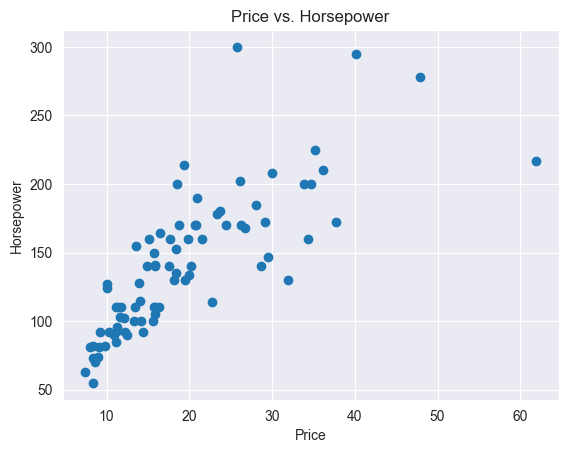

In [8]:
# d
plt.scatter(x=df['Price'], y=df['Horsepower'])
plt.title('Price vs. Horsepower')
plt.xlabel('Price')
plt.ylabel('Horsepower')

### 4. Neurale netwerken regressie

#### a. Train en test dataset voor predictors en target feature

In [9]:
X = df[['Cylinders', 'Horsepower', 'Passengers', 'Length']]
y = df[['Price']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.06, random_state=42)

#### b. definieer het model

In [10]:
# input layer 4 nodes
inputs = Input(shape=(4,))
# 2 hidden layer
x = Dense(128, activation='relu')(inputs)
x = Dense(64, activation='relu')(x)
# output layer
outputs = Dense(1, activation='linear')(x)
# construct the model
model = Model(inputs, outputs, name='predict-car-price')
# print a summary
model.summary()
# compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['r2_score']
)

Model: "predict-car-price"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,961 (35.00 KB)

 Trainable params: 8,961 (35.00 KB)

 Non-trainable params: 0 (0.00 B)

#### c. train het model

In [11]:
# train the model
model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - loss: 262.3162 - r2_score: -1.5486 - val_loss: 115.1131 - val_r2_score: -5.8171
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 129.4009 - r2_score: -0.0782 - val_loss: 51.1678 - val_r2_score: -2.0302
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 56.4376 - r2_score: 0.4168 - val_loss: 22.7258 - val_r2_score: -0.3458
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 71.9906 - r2_score: 0.3089 - val_loss: 34.1798 - val_r2_score: -1.0241
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 50.2291 - r2_score: 0.4697 - val_loss: 69.2094 - val_r2_score: -3.0986
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 52.5769 - r2_score: 0.5738 - val_loss: 144.8591 - val_r2_score: -7.5786
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 69.7063 - r2_score: 0.2547 - val_loss: 80.2671 - val_r2_score: -3.7535
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 47.8843 - r2_score: 0.6042 - val_loss: 7

#### d. Maak een voorspelling

In [12]:
new_data = np.array([[4, 200, 4, 190]])

model.predict(new_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


array([[33.30407]], dtype=float32)

### 5. Random forest grid search

#### a. Dataset voor predictors en target feature

In [13]:
X = df[['Price', 'Cylinders', 'Horsepower', 'Passengers', 'Length']]
y = df['Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)


#### b. Grid search

In [14]:
model = RandomForestClassifier()

# Define parameter grid (model specific)
grid_param = {
    'n_estimators': list(range(12, 18)),
    'max_depth': list(range(3, 6))}

grid_search = GridSearchCV(model, grid_param, cv=4)

# Execute full grid search
grid_search.fit(X_train, y_train)

# Display best hyperparameter values and matching validation score
print(f'Best parameters    : {grid_search.best_params_}')
print(f'Best accuracy score: {grid_search.best_score_}')

model = grid_search.best_estimator_

Best parameters    : {'max_depth': 5, 'n_estimators': 17}
Best accuracy score: 0.8055555555555556


#### c. Scores voor de test dataset

In [15]:
y_test_pred = model.predict(X_test)

print(classification_report(y_true=y_test, y_pred=y_test_pred))

              precision    recall  f1-score   support

     Compact       0.00      0.00      0.00         1
       Large       1.00      1.00      1.00         1
     Midsize       1.00      0.75      0.86         4
       Small       0.50      0.50      0.50         2
      Sporty       1.00      1.00      1.00         1

    accuracy                           0.67         9
   macro avg       0.70      0.65      0.67         9
weighted avg       0.78      0.67      0.71         9



### 6. Simulated annealing

#### a. Optimale fiets

In [22]:
A_kwal = np.array([9, 8, 9, 9, 9, 8, 9, 9, 8, 9])
B_kwal = np.array([7, 6, 7, 8, 6, 6, 8, 8, 7, 6])
A_prijs = np.array([300, 250, 350, 200, 300, 320, 150, 250, 450, 160])
B_prijs = np.array([200, 100, 300, 150, 250, 220, 50, 180, 350, 20])


class BikeProblem(Annealer):
    def energy(self):
        B_onderdelen = self.state  # In de B_onderdelen array zijn alle geselecteerde B-onderdelen gelijk aan 1
        A_onderdelen = - (
                B_onderdelen - 1)  # In de A_onderdelen array zijn alle geselecteerde A-onderdelen gelijk aan 1


        #price check, if price too high we return xxl number
        total_price = B_prijs[np.array(B_onderdelen, dtype=bool)].sum() + A_prijs[np.array(A_onderdelen, dtype=bool)].sum()
        if total_price > 2500:
            return 90000000

        total_quality = B_kwal[np.array(B_onderdelen, dtype=bool)].sum() + A_kwal[np.array(A_onderdelen, dtype=bool)].sum()

        return -total_quality

    def move(self):
        a = np.random.randint(0, len(self.state))

        if self.state[a] == 0:
            self.state[a] = 1
        else:
            self.state[a] = 0

initial_state = np.random.choice([0, 1], size=10)
bike_problem = BikeProblem(initial_state)
quality = bike_problem.anneal()

print(f'De array voor de optimale fiets met een prijs van maximum 2500 euro:\n'
      f'{quality[0]}')


 Temperature        Energy    Accept   Improve     Elapsed   Remaining


De array voor de optimale fiets met een prijs van maximum 2500 euro:
[0 1 0 0 0 0 0 0 1 0]


#### b. Prijs optimale fiets

In [23]:
total_price_external = B_prijs[np.array(quality[0], dtype=bool)].sum() + A_prijs[np.array(quality[0], dtype=bool)-1].sum()

print(f'De prijs van de optimale fiets: {total_price_external}')

De prijs van de optimale fiets: 2330
